# Amazon Drought Monitoring

## Project objective

This project explores drought-related changes in surface water and vegetation near Lake Tefé in the central Amazon using Python, Google Earth Engine, and satellite imagery.

## Research Question

How did the 2023–2024 drought affect surface water and surrounding vegetation in Lake Tefé, Central Amazon?

## Hypothesis

The severe drought reduced the surface water extent and increased vegetation stress around the lake.

In [1]:
import ee
import geemap

In [2]:
ee.Authenticate()

True

In [3]:
ee.Initialize(project='amazon-drought-project')

## Study Area

The study area covers Lake Tefé and its surrounding vegetation in Amazonas, Brazil.
An initial rectangular region is used for data exploration.

In [4]:
# Approximate center of Lake Tefé
#longitude = -64.70
#latitude = -3.35

# Initial rectangular area of interest
aoi = ee.Geometry.Rectangle([
    -65.10, -3.85,   # west, south
    -64.30, -2.95    # east, north
])

Map = geemap.Map()
Map.centerObject(aoi, 9)
Map.addLayer(aoi, {"color": "red"}, "Initial study area")
Map

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

In [5]:
def mask_s2_clouds(image):
    scl = image.select("SCL")

    clear_pixels = (
        scl.neq(3)   # Cloud shadow
        .And(scl.neq(8))   # Medium-probability cloud
        .And(scl.neq(9))   # High-probability cloud
        .And(scl.neq(10))  # Cirrus
        .And(scl.neq(11))  # Snow or ice
    )

    return image.updateMask(clear_pixels)

In [6]:
def create_composite(start_date, end_date):
    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 70))
        .map(mask_s2_clouds)
    )

    return collection.median().clip(aoi)

In [7]:
composite_2022 = create_composite("2022-09-01", "2022-12-01")

In [8]:
rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000
}

Map_2022 = geemap.Map()
Map_2022.centerObject(aoi, 9)

Map_2022.addLayer(
    composite_2022,
    rgb_vis,
    "RGB composite 2022"
)

Map_2022.addLayer(aoi, {"color": "red"}, "Study area")

Map_2022

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

## Surface Water Detection: Normalized Difference Water Index (NDWI)

To identify open water, the Normalized Difference Water Index (NDWI) is calculated from the green and near-infrared bands of Sentinel-2.

NDWI = (Green - NIR) / (Green + NIR)

In [9]:
ndwi_2022 = composite_2022.normalizedDifference(["B3", "B8"])

In [10]:
ndwi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["brown", "white", "blue"]
}

Map_2022.addLayer(
    ndwi_2022,
    ndwi_vis,
    "NDWI 2022"
)

Map_2022

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

## Water Mask

A binary water mask is derived from NDWI to separate likely surface water from non-water pixels.

An initial threshold of NDWI > 0 is used and will be evaluated visually before calculating water area.

In [11]:
water_2022 = ndwi_2022.gt(0)

## Water Area Estimation

The binary water mask is combined with pixel area to estimate the total surface-water area within the study area.

## Validation of the Water Mask

The estimated water area represents all pixels within the study area classified as water using NDWI > 0. Before temporal comparison, the spatial plausibility of this mask must be checked.


In [12]:
Map_check = geemap.Map()
Map_check.centerObject(aoi, 9)

Map_check.addLayer(
    composite_2022,
    rgb_vis,
    "RGB 2022"
)

Map_check.addLayer(
    water_2022.selfMask(),
    {"palette": ["blue"]},
    "Detected water"
)

Map_check

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

## 2023 Drought-period Analysis

The same processing workflow is applied to the corresponding period in 2023 to allow a consistent comparison with the 2022 reference period.

In [13]:
composite_2023 = create_composite(
    "2023-09-01",
    "2023-12-01"
)

ndwi_2023 = composite_2023.normalizedDifference(
    ["B3", "B8"]
)

water_2023 = ndwi_2023.gt(0)

Map_2023 = geemap.Map()
Map_2023.centerObject(aoi, 9)

Map_2023.addLayer(
    composite_2023,
    rgb_vis,
    "RGB 2023"
)

Map_2023.addLayer(
    water_2023.selfMask(),
    {"palette": ["blue"]},
    "Detected water 2023"
)

Map_2023

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

In [14]:
def calculate_water_area(water_mask):
    area_image = water_mask.multiply(
        ee.Image.pixelArea()
    )

    area = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    )

    area_m2 = area.get("nd").getInfo()

    return area_m2 / 1_000_000

In [15]:
water_area_km2_2022 = calculate_water_area(water_2022)
water_area_km2_2023 = calculate_water_area(water_2023)

print("2022:", round(water_area_km2_2022, 2), "km²")
print("2023:", round(water_area_km2_2023, 2), "km²")

2022: 702.55 km²
2023: 480.79 km²


## 2024 Water-area Analysis

The same workflow is applied to the corresponding period in 2024 to examine whether surface-water conditions recovered or remained anomalously low after the severe 2023 drought.

In [16]:
composite_2024 = create_composite(
    "2024-09-01",
    "2024-12-01"
)

ndwi_2024 = composite_2024.normalizedDifference(
    ["B3", "B8"]
)

water_2024 = ndwi_2024.gt(0)

water_area_km2_2024 = calculate_water_area(water_2024)

print(
    "Estimated water area in 2024:",
    round(water_area_km2_2024, 2),
    "km²"
)

Estimated water area in 2024: 402.11 km²


## Surface-water Change

Water-area estimates from 2022, 2023, and 2024 are compared to quantify the magnitude of surface-water change during the drought period.

In [17]:
change_2023 = water_area_km2_2023 - water_area_km2_2022
change_2024 = water_area_km2_2024 - water_area_km2_2022

percent_change_2023 = (
    change_2023 / water_area_km2_2022
) * 100

percent_change_2024 = (
    change_2024 / water_area_km2_2022
) * 100

print("Change 2022 → 2023:", round(percent_change_2023, 1), "%")
print("Change 2022 → 2024:", round(percent_change_2024, 1), "%")

Change 2022 → 2023: -31.6 %
Change 2022 → 2024: -42.8 %


## Results Table

The estimated surface-water areas and their changes relative to the 2022 reference period are organized in a Pandas DataFrame for further analysis and visualization.

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Year": [2022, 2023, 2024],
    "Water_Area_km2": [
        water_area_km2_2022,
        water_area_km2_2023,
        water_area_km2_2024
    ]
})

results

,Year,Water_Area_km2
0,2022,702.548829
1,2023,480.787225
2,2024,402.111795


In [19]:
baseline = results.loc[0, "Water_Area_km2"]

results["Change_km2"] = results["Water_Area_km2"] - baseline

results["Change_percent"] = (
    results["Change_km2"] / baseline
) * 100

results

,Year,Water_Area_km2,Change_km2,Change_percent
0,2022,702.548829,0.000000,0.000000
1,2023,480.787225,-221.761604,-31.565294
2,2024,402.111795,-300.437034,-42.763865


## Water-area Visualization

The estimated surface-water area is visualized to show the temporal change between 2022 and 2024.

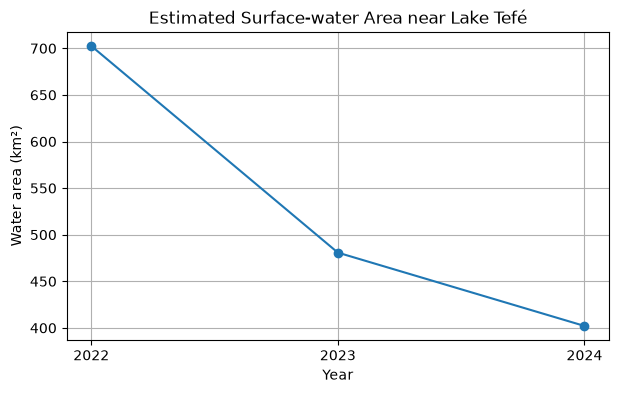

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    results["Year"],
    results["Water_Area_km2"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Water area (km²)")
plt.title("Estimated Surface-water Area near Lake Tefé")

plt.xticks([2022, 2023, 2024])

plt.grid(True)
plt.show()

## Preliminary Interpretation

The analysis indicates a substantial reduction in detected surface-water area relative to the 2022 reference period:

- 2023: approximately 31.6% lower than 2022.
- 2024: approximately 42.8% lower than 2022.

These results indicate a strong temporal change in surface-water extent within the study area. However, the estimates should not be interpreted as the exact area of Lake Tefé, since the analysis includes all pixels classified as water within the AOI.

The results are also sensitive to the selected NDWI threshold, cloud masking, seasonal timing, and the spatial definition of the study area.

## Vegetation Response

The Normalized Difference Vegetation Index (NDVI) is used to investigate changes in vegetation condition around the study area.

NDVI = (NIR - Red) / (NIR + Red)

In [21]:
ndvi_2022 = composite_2022.normalizedDifference(
    ["B8", "B4"]
)

In [22]:
ndvi_vis = {
    "min": -0.2,
    "max": 0.9,
    "palette": ["brown", "yellow", "lightgreen", "darkgreen"]
}

Map_ndvi = geemap.Map()
Map_ndvi.centerObject(aoi, 9)

Map_ndvi.addLayer(
    ndvi_2022,
    ndvi_vis,
    "NDVI 2022"
)

Map_ndvi

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

## Vegetation Mask

Water pixels are excluded before calculating vegetation statistics, so changes in lake extent do not directly bias the NDVI summary.

In [23]:
land_2022 = water_2022.Not()

ndvi_land_2022 = ndvi_2022.updateMask(land_2022)

In [24]:
mean_ndvi_2022 = ndvi_land_2022.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("nd").getInfo()

print("Mean land NDVI in 2022:", round(mean_ndvi_2022, 3))

Mean land NDVI in 2022: 0.778


## NDVI Comparison Across Years

The same land-masking and NDVI calculation are applied to 2023 and 2024 to maintain methodological consistency across the three periods.

In [25]:
# 2023
ndvi_2023 = composite_2023.normalizedDifference(
    ["B8", "B4"]
)

land_2023 = water_2023.Not()
ndvi_land_2023 = ndvi_2023.updateMask(land_2023)

mean_ndvi_2023 = ndvi_land_2023.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("nd").getInfo()

In [26]:
# 2024
ndvi_2024 = composite_2024.normalizedDifference(
    ["B8", "B4"]
)

land_2024 = water_2024.Not()
ndvi_land_2024 = ndvi_2024.updateMask(land_2024)

mean_ndvi_2024 = ndvi_land_2024.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("nd").getInfo()

In [27]:
print("Mean land NDVI in 2022:", round(mean_ndvi_2022, 3))
print("Mean land NDVI in 2023:", round(mean_ndvi_2023, 3))
print("Mean land NDVI in 2024:", round(mean_ndvi_2024, 3))

Mean land NDVI in 2022: 0.778
Mean land NDVI in 2023: 0.743
Mean land NDVI in 2024: 0.748


## Water-masked NDVI Change

Water pixels detected in either comparison year are excluded from the NDVI change analysis. This prevents changes in water extent from being interpreted as vegetation change.

In [28]:
ndvi_change_vis = {
    "min": -0.3,
    "max": 0.3,
    "palette": ["red", "white", "green"]
}

common_land_2022_2023 = water_2022.Not().And(
    water_2023.Not()
)

ndvi_change_2023_land = (
    ndvi_2023
    .subtract(ndvi_2022)
    .updateMask(common_land_2022_2023)
)

Map_change = geemap.Map()
Map_change.centerObject(aoi, 9)

Map_change.addLayer(
    ndvi_change_2023_land,
    ndvi_change_vis,
    "Land NDVI change 2022-2023"
)

Map_change

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

## NDVI Change in 2024

The 2024 NDVI is compared with the 2022 reference period using the same common-land masking approach.

In [29]:
common_land_2022_2024 = water_2022.Not().And(
    water_2024.Not()
)

ndvi_change_2024_land = (
    ndvi_2024
    .subtract(ndvi_2022)
    .updateMask(common_land_2022_2024)
)

Map_change_2024 = geemap.Map()
Map_change_2024.centerObject(aoi, 9)

Map_change_2024.addLayer(
    ndvi_change_2024_land,
    ndvi_change_vis,
    "Land NDVI change 2022-2024"
)

Map_change_2024

Map(center=[-3.4000126600282234, -64.70000000000029], controls=(WidgetControl(options=['position', 'transparen…

## Mean NDVI Change

The mean NDVI difference is calculated over pixels classified as land in both the reference year and the comparison year.

In [30]:
mean_ndvi_change_2023 = ndvi_change_2023_land.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("nd").getInfo()

mean_ndvi_change_2024 = ndvi_change_2024_land.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("nd").getInfo()

print(
    "Mean NDVI change 2022 → 2023:",
    round(mean_ndvi_change_2023, 3)
)

print(
    "Mean NDVI change 2022 → 2024:",
    round(mean_ndvi_change_2024, 3)
)

Mean NDVI change 2022 → 2023: -0.022
Mean NDVI change 2022 → 2024: -0.014


## Combined Water and Vegetation Results

Surface-water area and mean land NDVI are combined into a single results table to summarize the observed environmental changes between 2022 and 2024.

In [31]:
results["Mean_Land_NDVI"] = [
    mean_ndvi_2022,
    mean_ndvi_2023,
    mean_ndvi_2024
]

results["NDVI_change_from_2022"] = [
    0,
    mean_ndvi_change_2023,
    mean_ndvi_change_2024
]

results.round(3)

,Year,Water_Area_km2,Change_km2,Change_percent,Mean_Land_NDVI,NDVI_change_from_2022
0,2022,702.549,0.000,0.000,0.778,0.000
1,2023,480.787,-221.762,-31.565,0.743,-0.022
2,2024,402.112,-300.437,-42.764,0.748,-0.014


## Precipitation Analysis

Precipitation is analyzed for the same September–November period used in the Sentinel-2 analysis.

CHIRPS Daily precipitation data are used to compare rainfall conditions across 2022, 2023, and 2024.

In [32]:
def calculate_precipitation(start_date, end_date):
    precipitation = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .sum()
    )

    mean_precipitation = precipitation.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=5000,
        maxPixels=1e9
    ).get("precipitation").getInfo()

    return mean_precipitation

In [33]:
precip_2022 = calculate_precipitation(
    "2022-09-01", "2022-12-01"
)

precip_2023 = calculate_precipitation(
    "2023-09-01", "2023-12-01"
)

precip_2024 = calculate_precipitation(
    "2024-09-01", "2024-12-01"
)

print("2022:", round(precip_2022, 1), "mm")
print("2023:", round(precip_2023, 1), "mm")
print("2024:", round(precip_2024, 1), "mm")

2022: 384.3 mm
2023: 385.9 mm
2024: 406.0 mm


## Annual Precipitation Context

Because lake-water extent may respond to cumulative hydrological conditions rather than rainfall during the observation period alone, precipitation is also evaluated from January through November for each year.

In [34]:
precip_jan_nov_2022 = calculate_precipitation(
    "2022-01-01", "2022-12-01"
)

precip_jan_nov_2023 = calculate_precipitation(
    "2023-01-01", "2023-12-01"
)

precip_jan_nov_2024 = calculate_precipitation(
    "2024-01-01", "2024-12-01"
)

print("Jan-Nov 2022:", round(precip_jan_nov_2022, 1), "mm")
print("Jan-Nov 2023:", round(precip_jan_nov_2023, 1), "mm")
print("Jan-Nov 2024:", round(precip_jan_nov_2024, 1), "mm")

Jan-Nov 2022: 2283.8 mm
Jan-Nov 2023: 2359.9 mm
Jan-Nov 2024: 2063.4 mm


## Environmental Context

Precipitation totals are included as supporting environmental context. They are not used to infer a direct causal relationship with surface-water change, as lake extent can also reflect catchment-scale hydrology, river discharge, antecedent conditions, and other processes.

In [35]:
results["Precip_SepNov_mm"] = [
    precip_2022,
    precip_2023,
    precip_2024
]

results["Precip_JanNov_mm"] = [
    precip_jan_nov_2022,
    precip_jan_nov_2023,
    precip_jan_nov_2024
]

results.round(2)

,Year,Water_Area_km2,Change_km2,Change_percent,Mean_Land_NDVI,NDVI_change_from_2022,Precip_SepNov_mm,Precip_JanNov_mm
0,2022,702.55,0.00,0.00,0.78,0.00,384.33,2283.80
1,2023,480.79,-221.76,-31.57,0.74,-0.02,385.88,2359.90
2,2024,402.11,-300.44,-42.76,0.75,-0.01,405.97,2063.38


## Final Results Visualization

Surface-water area and mean land NDVI are visualized separately to summarize the main temporal patterns observed between 2022 and 2024.

## Exporting Results

Tabular results and final figures are exported to the project directories for reuse in the GitHub repository and documentation.

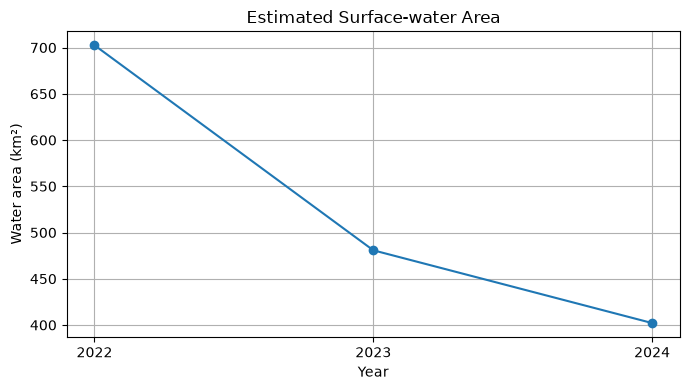

In [36]:
results.to_csv(
    "../data/results_summary.csv",
    index=False
)

plt.figure(figsize=(7, 4))

plt.plot(
    results["Year"],
    results["Water_Area_km2"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Water area (km²)")
plt.title("Estimated Surface-water Area")
plt.grid(True)
plt.xticks([2022, 2023, 2024])
plt.tight_layout()

plt.savefig(
    "../figures/water_area_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


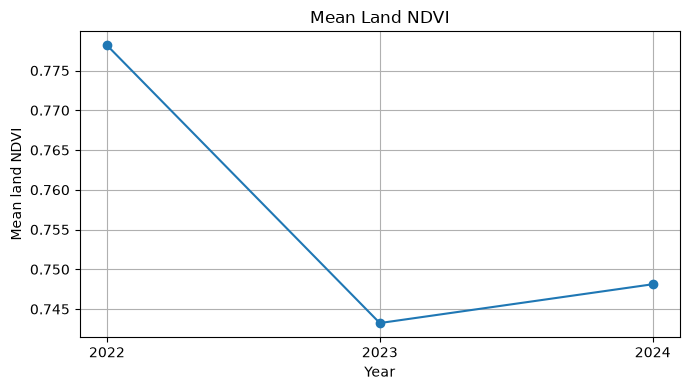

In [37]:
plt.figure(figsize=(7, 4))

plt.plot(
    results["Year"],
    results["Mean_Land_NDVI"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean land NDVI")
plt.title("Mean Land NDVI")
plt.grid(True)
plt.xticks([2022, 2023, 2024])
plt.tight_layout()

plt.savefig(
    "../figures/mean_land_ndvi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Exporting Interactive Maps

Interactive maps are exported as HTML files so the spatial results can be inspected outside the Jupyter Notebook.

In [38]:
Map_check.to_html(
    "../docs/water_detection_2022.html"
)

Map_change.to_html(
    "../docs/ndvi_change_2022_2023.html"
)

Map_change_2024.to_html(
    "../docs/ndvi_change_2022_2024.html"
)


## Project Outputs

The project produces three main output types:

1. Tabular summaries of surface-water area, NDVI, and precipitation.
2. Static figures summarizing temporal changes.
3. Interactive maps for spatial inspection of water detection and NDVI change.